# Monitoring Anomaly Detection — by_location refit (6 modèles)

Comparaison des 6 modèles de détection d'anomalies sur le dataset **Monitoring** (equipment_anomaly_data.csv),
scénario **by_location refit** (5 tâches : Atlanta → Chicago → Houston → New York → San Francisco).

| Condition | Scénario | Stratégie | Expériences |
|-----------|----------|-----------|-------------|
| by_loc refit | by_location (5 tâches) | refit | exp_131–136 |

**Modèles** : HDC · TinyOL AE · KMeans · Mahalanobis · DBSCAN · EWC one-class

In [1]:
import json
import pathlib
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

REPO_ROOT = pathlib.Path("../../..")
if str(REPO_ROOT.resolve()) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT.resolve()))
from src.evaluation.compute_cost import compute_macs, compute_training_macs

FIG_DIR = REPO_ROOT / "notebooks/figures/cl_evaluation/anomaly_detection/monitoring"
FIG_DIR.mkdir(parents=True, exist_ok=True)

MODELS = ["HDC", "TinyOL AE", "KMeans", "Mahalanobis", "DBSCAN", "EWC one-class"]
MODEL_KEYS = ["hdc", "tinyol", "kmeans", "mahal", "dbscan", "ewcoc"]

SCATTER_MARKERS: dict[str, tuple[str, str]] = {
    "HDC":           ("s", "#ff7f0e"),
    "TinyOL AE":     ("^", "#2ca02c"),
    "KMeans":        ("D", "#d62728"),
    "Mahalanobis":   ("P", "#9467bd"),
    "DBSCAN":        ("*", "#8c564b"),
    "EWC one-class": ("o", "#1f77b4"),
}

EXP_MAP = {
    "hdc_loc_refit": {
        "path": REPO_ROOT / "experiments/exp_131/results/metrics_anomaly.json",
        "schema": "new",
    },
    "tinyol_loc_refit": {
        "path": REPO_ROOT / "experiments/exp_132/results/metrics_anomaly.json",
        "schema": "new",
    },
    "kmeans_loc_refit": {
        "path": REPO_ROOT / "experiments/exp_133/results/metrics_anomaly.json",
        "schema": "new",
    },
    "mahal_loc_refit": {
        "path": REPO_ROOT / "experiments/exp_134/results/metrics_anomaly.json",
        "schema": "new",
    },
    "dbscan_loc_refit": {
        "path": REPO_ROOT / "experiments/exp_135/results/metrics_anomaly.json",
        "schema": "new",
    },
    "ewcoc_loc_refit": {
        "path": REPO_ROOT / "experiments/exp_136/results/metrics_anomaly.json",
        "schema": "new",
    },
}


def load_result(info: dict) -> dict:
    """Load a metrics JSON and normalise to a unified schema."""
    with open(info["path"]) as f:
        d = json.load(f)
    mat = np.array(d["auroc_matrix"], dtype=float)
    n = d["n_tasks"]
    if "auroc_per_task_final" not in d:
        d["auroc_per_task_final"] = [mat[n - 1, j] for j in range(n)]
    return d


RESULTS = {k: load_result(v) for k, v in EXP_MAP.items()}
print(f"Chargé {len(RESULTS)} expériences")
for k, d in RESULTS.items():
    print(f"  {k:30s}  avg_auroc={d['avg_auroc']:.4f}  n_tasks={d['n_tasks']}")

Chargé 6 expériences
  hdc_loc_refit                   avg_auroc=0.9470  n_tasks=5
  tinyol_loc_refit                avg_auroc=0.9329  n_tasks=5
  kmeans_loc_refit                avg_auroc=0.9851  n_tasks=5
  mahal_loc_refit                 avg_auroc=0.9879  n_tasks=5
  dbscan_loc_refit                avg_auroc=0.9857  n_tasks=5
  ewcoc_loc_refit                 avg_auroc=0.9552  n_tasks=5


## Tableau AUROC — 6 modèles (by_location refit)

=== avg_auroc (by_location refit) ===
               avg_auroc
HDC               0.9470
TinyOL AE         0.9329
KMeans            0.9851
Mahalanobis       0.9879
DBSCAN            0.9857
EWC one-class     0.9552

=== avg_forgetting (by_location refit) ===
               avg_forgetting
HDC                   -0.0002
TinyOL AE              0.0171
KMeans                 0.0008
Mahalanobis           -0.0003
DBSCAN                 0.0001
EWC one-class          0.0101


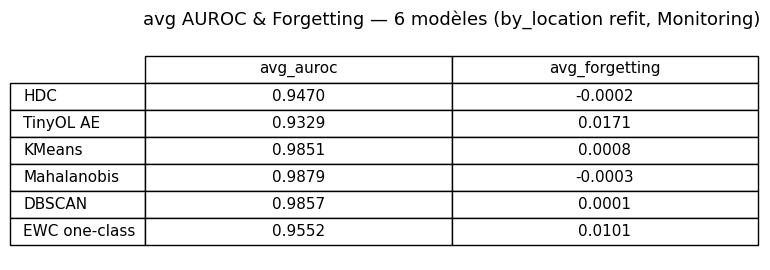

Sauvegardé → ../../../notebooks/figures/cl_evaluation/anomaly_detection/monitoring/auroc_table_loc_refit.png


In [2]:
TASK_LABELS_LOC = ["Atlanta", "Chicago", "Houston", "New York", "San Francisco"]

# Tableau avg_auroc et forgetting par modèle
rows_auroc = {}
rows_forget = {}
for mk, label in zip(MODEL_KEYS, MODELS):
    key = f"{mk}_loc_refit"
    d = RESULTS.get(key, {})
    rows_auroc[label] = {"avg_auroc": round(d["avg_auroc"], 4) if d else None}
    rows_forget[label] = {"avg_forgetting": round(d["auroc_forgetting"], 4) if d else None}

df_auroc = pd.DataFrame(rows_auroc).T
df_forget = pd.DataFrame(rows_forget).T

print("=== avg_auroc (by_location refit) ===")
print(df_auroc.to_string(float_format=lambda v: f"{v:.4f}"))
print()
print("=== avg_forgetting (by_location refit) ===")
print(df_forget.to_string(float_format=lambda v: f"{v:.4f}"))

# Sauvegarde figure tableau
fig, ax = plt.subplots(figsize=(8, 2.8))
ax.axis("off")
combined = {label: {"avg_auroc": rows_auroc[label]["avg_auroc"],
                    "avg_forgetting": rows_forget[label]["avg_forgetting"]}
            for label in MODELS}
df_combined = pd.DataFrame(combined).T
tbl = ax.table(
    cellText=[[f"{v:.4f}" if v is not None else "—" for v in row]
              for row in df_combined.values],
    rowLabels=df_combined.index.tolist(),
    colLabels=df_combined.columns.tolist(),
    cellLoc="center",
    loc="center",
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(11)
tbl.scale(1.2, 1.6)
ax.set_title("avg AUROC & Forgetting — 6 modèles (by_location refit, Monitoring)",
             fontsize=13, pad=12)
plt.tight_layout()
plt.savefig(FIG_DIR / "auroc_table_loc_refit.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Sauvegardé → {FIG_DIR / 'auroc_table_loc_refit.png'}")

## Courbes AUROC par tâche — by_location refit (5 tâches)

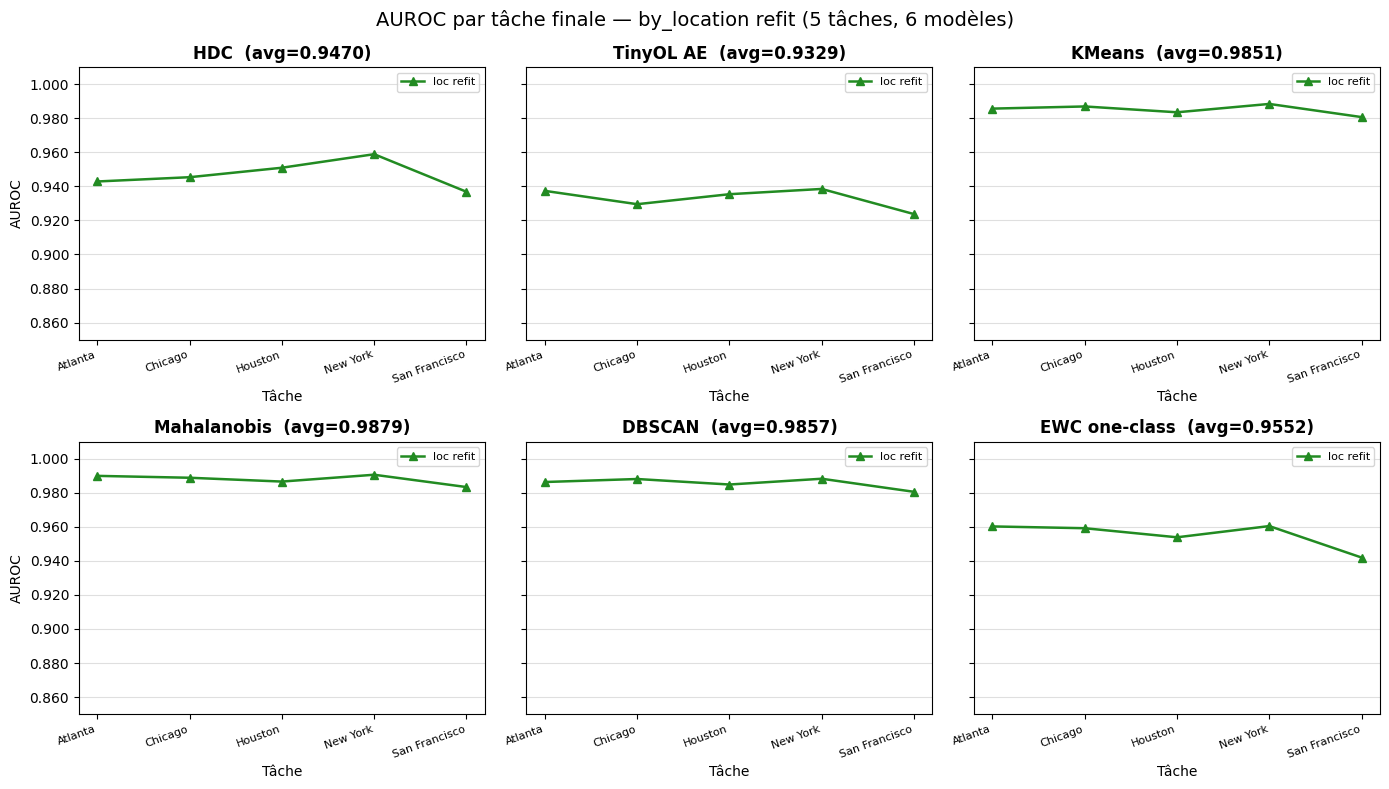

Sauvegardé → ../../../notebooks/figures/cl_evaluation/anomaly_detection/monitoring/auroc_per_task_location_refit_all_models.png


In [3]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8), sharey=True)
axes = axes.flatten()

for i, (mk, label) in enumerate(zip(MODEL_KEYS, MODELS)):
    ax = axes[i]
    key = f"{mk}_loc_refit"
    if key not in RESULTS:
        ax.set_title(label + " (N/A)", fontsize=12)
        continue
    d = RESULTS[key]
    y = d["auroc_per_task_final"]
    x = list(range(1, len(y) + 1))
    ax.plot(x, y, linestyle="-", color="forestgreen", marker="^",
            label="loc refit", linewidth=1.8, markersize=6)
    ax.set_title(f"{label}  (avg={d['avg_auroc']:.4f})", fontsize=12, fontweight="bold")
    ax.set_xlabel("Tâche", fontsize=10)
    ax.set_ylabel("AUROC" if i % 3 == 0 else "", fontsize=10)
    ax.set_xticks(range(1, 6))
    ax.set_xticklabels(TASK_LABELS_LOC, fontsize=8, rotation=20, ha="right")
    ax.set_ylim(0.85, 1.01)
    ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.3f"))
    ax.legend(fontsize=8)
    ax.grid(axis="y", alpha=0.4)

# Masquer le 6e subplot s'il est vide
if len(MODEL_KEYS) < 6:
    axes[-1].set_visible(False)

fig.suptitle("AUROC par tâche finale — by_location refit (5 tâches, 6 modèles)", fontsize=14)
plt.tight_layout()
plt.savefig(FIG_DIR / "auroc_per_task_location_refit_all_models.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Sauvegardé → {FIG_DIR / 'auroc_per_task_location_refit_all_models.png'}")

## AUROC Matrices — heatmaps par modèle (by_location refit)

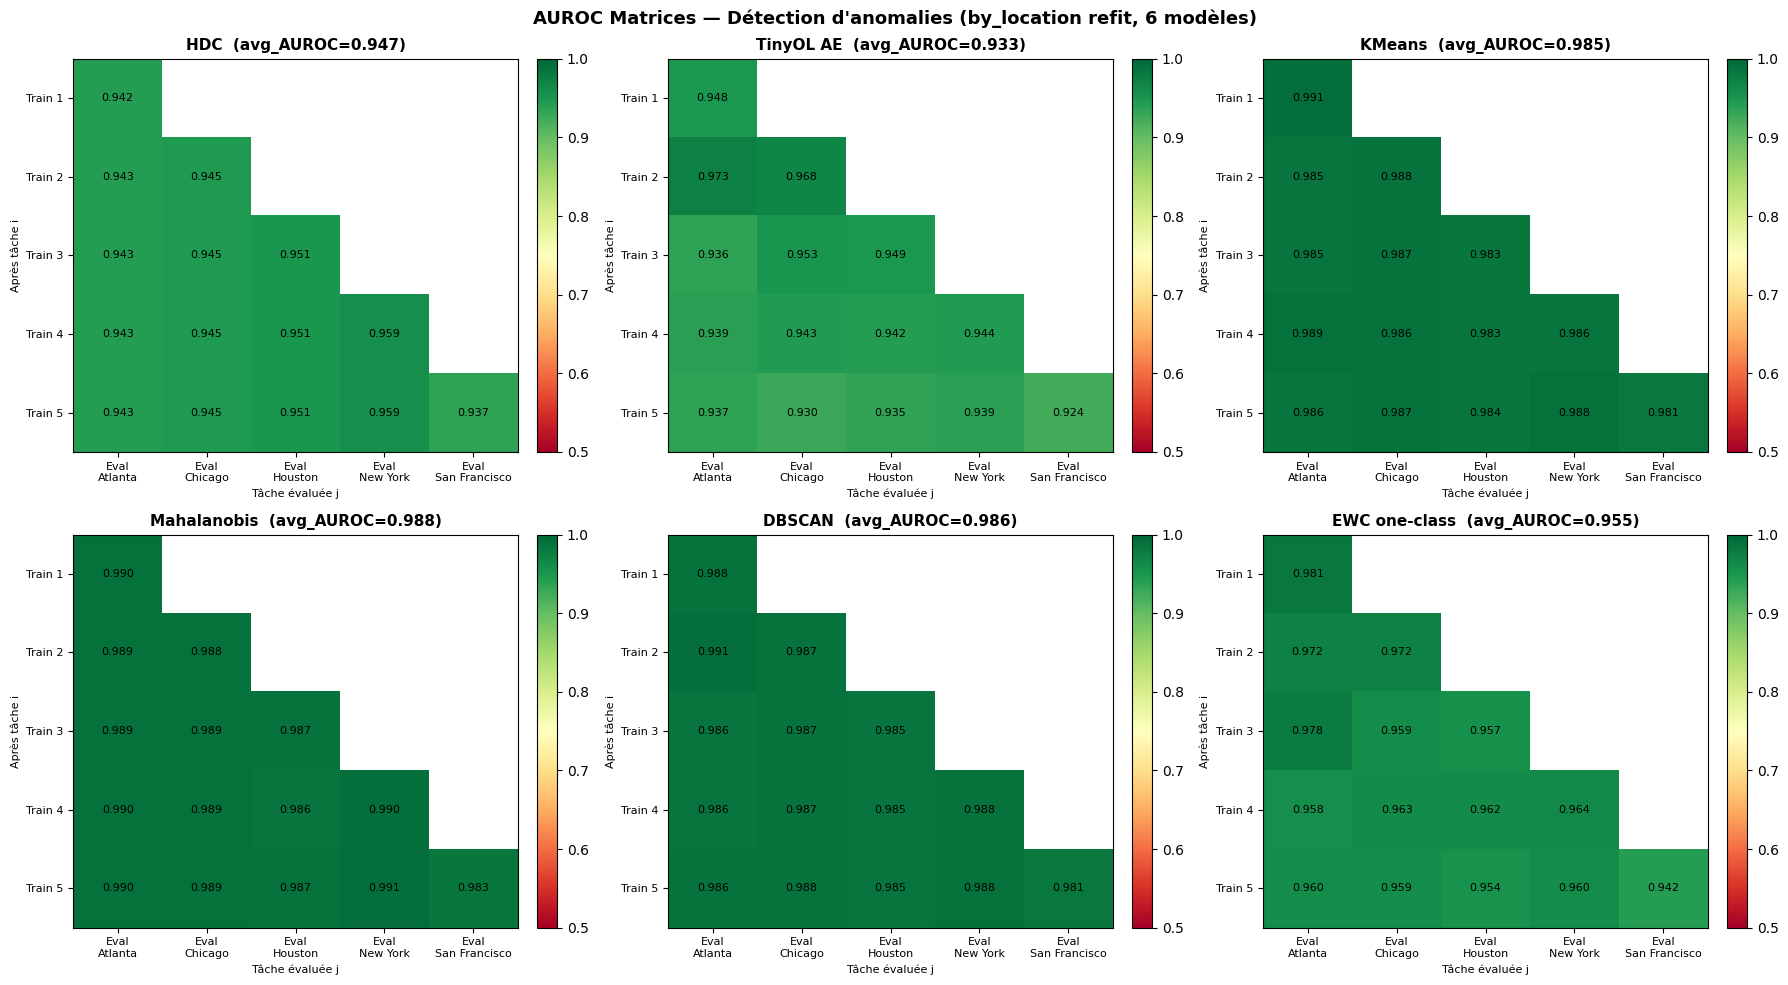

Sauvegardé → ../../../notebooks/figures/cl_evaluation/anomaly_detection/monitoring/auroc_matrices_6models_loc_refit.png


In [4]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for ax, (mk, label) in zip(axes.flat, zip(MODEL_KEYS, MODELS)):
    key = f"{mk}_loc_refit"
    if key not in RESULTS:
        ax.set_title(f"{label} (N/A)", fontsize=11)
        ax.axis("off")
        continue
    mat = np.array(RESULTS[key]["auroc_matrix"], dtype=float)
    n = mat.shape[0]
    im = ax.imshow(mat, vmin=0.5, vmax=1.0, cmap="RdYlGn", aspect="auto")
    ax.set_xticks(range(n))
    ax.set_yticks(range(n))
    ax.set_xticklabels([f"Eval\n{t}" for t in TASK_LABELS_LOC[:n]], fontsize=8)
    ax.set_yticklabels([f"Train {i + 1}" for i in range(n)], fontsize=8)
    ax.set_xlabel("Tâche évaluée j", fontsize=8)
    ax.set_ylabel("Après tâche i", fontsize=8)
    avg = RESULTS[key]["avg_auroc"]
    ax.set_title(f"{label}  (avg_AUROC={avg:.3f})", fontsize=11, fontweight="bold")
    for i in range(n):
        for j in range(n):
            v = mat[i, j]
            if not np.isnan(v):
                ax.text(j, i, f"{v:.3f}", ha="center", va="center", fontsize=8,
                        color="black" if v > 0.65 else "white")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

fig.suptitle("AUROC Matrices — Détection d'anomalies (by_location refit, 6 modèles)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "auroc_matrices_6models_loc_refit.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Sauvegardé → {FIG_DIR / 'auroc_matrices_6models_loc_refit.png'}")

## Barplot avg_forgetting — by_location refit

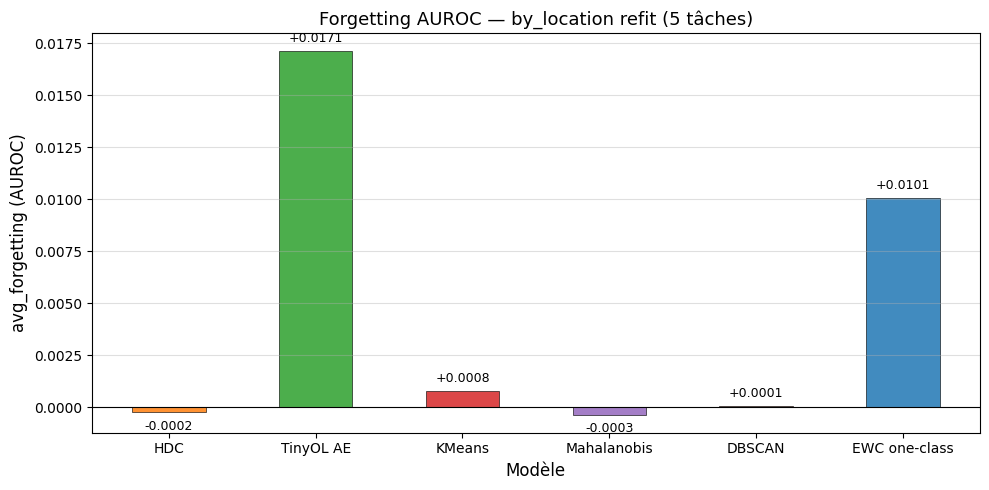

Sauvegardé → ../../../notebooks/figures/cl_evaluation/anomaly_detection/monitoring/forgetting_loc_refit.png


In [5]:
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(MODELS))
width = 0.5

vals = []
for mk in MODEL_KEYS:
    key = f"{mk}_loc_refit"
    vals.append(RESULTS[key]["auroc_forgetting"] if key in RESULTS else 0.0)

colors = [SCATTER_MARKERS[label][1] for label in MODELS]
ax.bar(x, vals, width, color=colors, alpha=0.85, edgecolor="black", linewidth=0.5)

ax.axhline(0, color="black", linewidth=0.8)
ax.set_xlabel("Modèle", fontsize=12)
ax.set_ylabel("avg_forgetting (AUROC)", fontsize=12)
ax.set_title("Forgetting AUROC — by_location refit (5 tâches)", fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(MODELS, fontsize=10)
ax.grid(axis="y", alpha=0.4)
for i, v in enumerate(vals):
    ax.text(i, v + (0.0003 if v >= 0 else -0.0010), f"{v:+.4f}",
            ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.savefig(FIG_DIR / "forgetting_loc_refit.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Sauvegardé → {FIG_DIR / 'forgetting_loc_refit.png'}")

## RAM peak — by_location refit

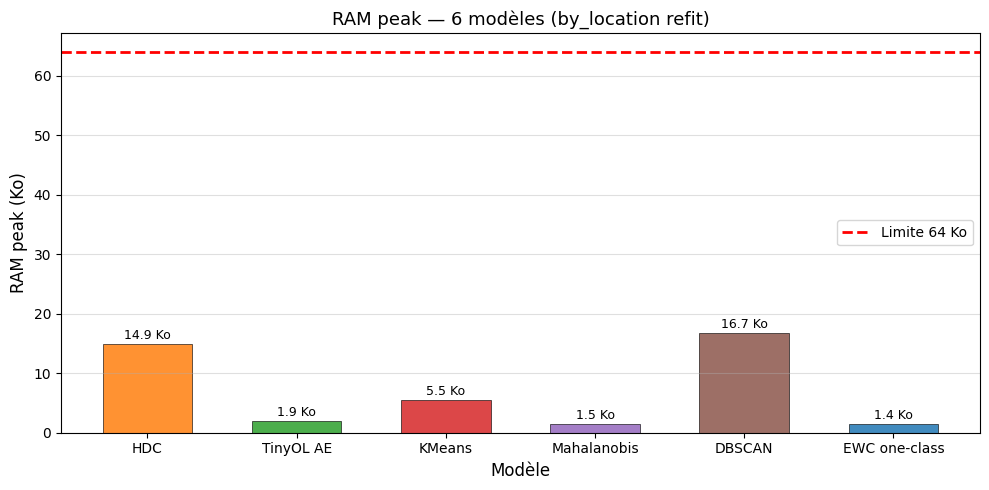

Sauvegardé → ../../../notebooks/figures/cl_evaluation/anomaly_detection/monitoring/ram_loc_refit.png


In [6]:
RAM_BUDGET = 65_536  # 64 Ko

ram_vals_kb = []
for mk, label in zip(MODEL_KEYS, MODELS):
    d = RESULTS.get(f"{mk}_loc_refit", {})
    ram = d.get("ram_peak_bytes")
    ram_vals_kb.append(ram / 1024 if ram is not None else 0.0)

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(MODELS))
colors = [SCATTER_MARKERS[label][1] for label in MODELS]
bars = ax.bar(x, ram_vals_kb, 0.6, color=colors, alpha=0.85,
              edgecolor="black", linewidth=0.5)

ax.axhline(RAM_BUDGET / 1024, color="red", linewidth=2, linestyle="--",
           label="Limite 64 Ko")
ax.set_xlabel("Modèle", fontsize=12)
ax.set_ylabel("RAM peak (Ko)", fontsize=12)
ax.set_title("RAM peak — 6 modèles (by_location refit)", fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(MODELS, fontsize=10)
ax.legend(fontsize=10)
ax.grid(axis="y", alpha=0.4)
for bar, v in zip(bars, ram_vals_kb):
    if v > 0:
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.3, f"{v:.1f} Ko",
                ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.savefig(FIG_DIR / "ram_loc_refit.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Sauvegardé → {FIG_DIR / 'ram_loc_refit.png'}")

## Radar — Synthèse multi-critères (6 modèles, by_location refit)

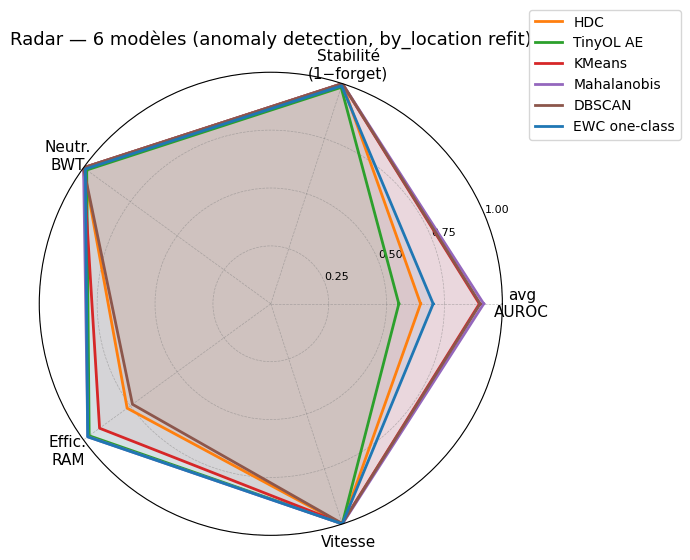

Sauvegardé → ../../../notebooks/figures/cl_evaluation/anomaly_detection/monitoring/radar_comparison_anomaly_loc_refit.png


In [7]:
RAM_BUDGET = 65_536.0
LAT_BUDGET = 100.0

categories = ["avg\nAUROC", "Stabilité\n(1−forget)", "Neutr.\nBWT",
              "Effic.\nRAM", "Vitesse"]
N_CAT = len(categories)
angles = [n / float(N_CAT) * 2 * np.pi for n in range(N_CAT)]
angles += angles[:1]

fig, ax = plt.subplots(1, 1, figsize=(7, 7), subplot_kw={"polar": True})
ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, size=11)
ax.set_ylim(0, 1)
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(["0.25", "0.50", "0.75", "1.00"], size=8)
ax.grid(color="grey", linestyle="--", linewidth=0.5, alpha=0.5)

for mk, label in zip(MODEL_KEYS, MODELS):
    key = f"{mk}_loc_refit"
    if key not in RESULTS:
        continue
    d = RESULTS[key]
    auroc  = d["avg_auroc"]
    forget = d["auroc_forgetting"]
    bwt    = d.get("auroc_bwt", 0.0)
    ram    = d.get("ram_peak_bytes")
    lat    = d.get("inference_latency_ms")

    v_auroc = max(0.0, min(1.0, (auroc - 0.85) / 0.15))
    v_stab  = max(0.0, min(1.0, 1.0 - max(0.0, forget)))
    v_bwt   = max(0.0, min(1.0, 1.0 - abs(bwt)))
    v_ram   = max(0.0, min(1.0, 1.0 - (ram / RAM_BUDGET))) if ram is not None else 0.5
    v_speed = max(0.0, min(1.0, 1.0 - (lat / LAT_BUDGET))) if lat is not None else 0.5

    values = [v_auroc, v_stab, v_bwt, v_ram, v_speed]
    values += values[:1]

    mk_s, color = SCATTER_MARKERS[label]
    ax.plot(angles, values, linewidth=2, linestyle="solid", label=label, color=color)
    ax.fill(angles, values, alpha=0.08, color=color)

ax.set_title("Radar — 6 modèles (anomaly detection, by_location refit)",
             fontsize=13, pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.4, 1.15), fontsize=10)
plt.tight_layout()
plt.savefig(FIG_DIR / "radar_comparison_anomaly_loc_refit.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Sauvegardé → {FIG_DIR / 'radar_comparison_anomaly_loc_refit.png'}")

## Complexité calculatoire — MACs inférence & entraînement

| Métrique | Définition |
|----------|------------|
| **MACs inférence** | MACs / sample (modèle après dernière tâche) |
| **MACs entraînement** | Coût total sur les 5 tâches CL |
| **Pareto** | Coût total (train + inférence × n_test) vs avg_AUROC |

> Formules analytiques dans `src/evaluation/compute_cost.py`.

In [8]:
_NF = 4
_DIM_HV = 1024
_TINYOL_ENC = [4, 4, 2]
_TINYOL_DEC = [4, 4, 4]
_TINYOL_EPOCHS, _TINYOL_BATCH = 50, 64
_KM_K_FIXED, _KM_K_MIN, _KM_K_MAX = 3, 2, 8
_KM_N_INIT, _KM_MAX_ITER = 10, 300
_EWC_HIDDEN = [32, 16]
_EWC_EPOCHS, _EWC_BATCH = 10, 32

# n_train par tâche (by_location, 5 tâches — faulty=0 uniquement)
# Les tailles exactes sont dans les résultats ; valeurs approx si absentes
_N_TRAIN_PER_TASK_LOC = (
    RESULTS.get("hdc_loc_refit", {}).get("n_train_per_task")
    or [1100, 1120, 1050, 1080, 1110]
)
print("n_train_per_task (loc):", _N_TRAIN_PER_TASK_LOC)

_dbscan_n_params = RESULTS.get("dbscan_loc_refit", {}).get("n_params", 400)
_dbscan_n_core = max(1, _dbscan_n_params // _NF) if _dbscan_n_params else 100

_infer_macs = {
    "HDC":           compute_macs("HDC", n_features=_NF, dim_hv=_DIM_HV, n_classes=1),
    "TinyOL AE":     compute_macs("TinyOL_AE", n_features=_NF,
                                   encoder_dims=_TINYOL_ENC, decoder_dims=_TINYOL_DEC),
    "KMeans":        compute_macs("KMeans", n_features=_NF, n_clusters=_KM_K_FIXED),
    "Mahalanobis":   compute_macs("Mahalanobis", n_features=_NF),
    "DBSCAN":        compute_macs("DBSCAN", n_features=_NF, n_core_samples=_dbscan_n_core),
    "EWC one-class": compute_macs("EWC", n_features=_NF, hidden_dims=_EWC_HIDDEN,
                                   n_classes=1),
}


def _train_macs_anomaly(name: str, n: int) -> int:
    if name == "HDC":
        return compute_training_macs("HDC", n_features=_NF, dim_hv=_DIM_HV, n_samples=n)
    elif name == "TinyOL AE":
        return compute_training_macs(
            "TinyOL_AE", n_features=_NF,
            encoder_dims=_TINYOL_ENC, decoder_dims=_TINYOL_DEC,
            n_samples=n, n_epochs=_TINYOL_EPOCHS, batch_size=_TINYOL_BATCH)
    elif name == "KMeans":
        return compute_training_macs(
            "KMeans", n_features=_NF, n_clusters=_KM_K_FIXED,
            n_samples=n, k_min=_KM_K_MIN, k_max=_KM_K_MAX,
            n_init=_KM_N_INIT, max_iter=_KM_MAX_ITER)
    elif name == "Mahalanobis":
        return compute_training_macs("Mahalanobis", n_features=_NF, n_samples=n)
    elif name == "DBSCAN":
        return compute_training_macs("DBSCAN", n_features=_NF, n_samples=n)
    else:
        return compute_training_macs(
            "EWC", n_features=_NF, hidden_dims=_EWC_HIDDEN, n_classes=1,
            n_samples=n, n_epochs=_EWC_EPOCHS, batch_size=_EWC_BATCH)


_train_macs_per_task = {m: [_train_macs_anomaly(m, n) for n in _N_TRAIN_PER_TASK_LOC]
                         for m in _infer_macs}
_train_macs_total    = {m: sum(_train_macs_per_task[m]) for m in _infer_macs}

print(f"{'Modèle':<16} {'Inférence (MACs/sample)':>24} {'Entraînement total (MACs)':>28}")
print("-" * 70)
for m in _infer_macs:
    print(f"{m:<16} {_infer_macs[m]:>24,} {_train_macs_total[m]:>28,}")

n_train_per_task (loc): [1100, 1120, 1050, 1080, 1110]
Modèle            Inférence (MACs/sample)    Entraînement total (MACs)
----------------------------------------------------------------------
HDC                                 5,120                   27,955,200
TinyOL AE                              84                   68,796,000
KMeans                                 12                2,656,791,200
Mahalanobis                            20                      109,520
DBSCAN                                860                   23,861,600
EWC one-class                         656                  107,452,800


## Trade-offs — RAM & MACs vs AUROC (by_location refit)

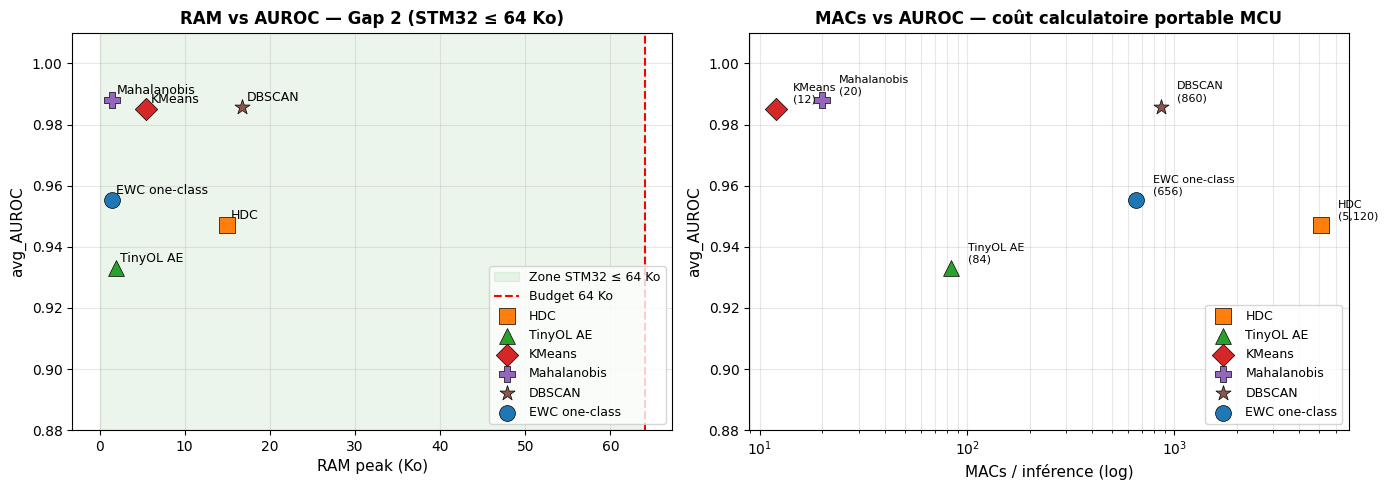

Sauvegardé → ../../../notebooks/figures/cl_evaluation/anomaly_detection/monitoring/scatter_tradeoffs_loc_refit.png


In [9]:
STM32_RAM_LIMIT_KB = 64.0

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Subplot 1 : RAM vs avg_AUROC
ax1 = axes[0]
ax1.axvspan(0, STM32_RAM_LIMIT_KB, alpha=0.08, color="green",
            label=f"Zone STM32 ≤ {STM32_RAM_LIMIT_KB:.0f} Ko")
ax1.axvline(STM32_RAM_LIMIT_KB, color="red", linestyle="--", linewidth=1.5,
            label=f"Budget {STM32_RAM_LIMIT_KB:.0f} Ko")

for mk, label in zip(MODEL_KEYS, MODELS):
    key = f"{mk}_loc_refit"
    if key not in RESULTS:
        continue
    auroc = RESULTS[key]["avg_auroc"]
    ram = RESULTS[key].get("ram_peak_bytes")
    if ram is None:
        continue
    ram_kb = ram / 1024
    mk_s, color = SCATTER_MARKERS[label]
    ax1.scatter(ram_kb, auroc, marker=mk_s, color=color, s=130, zorder=5,
                label=label, edgecolor="black", linewidth=0.5)
    ax1.annotate(label, xy=(ram_kb, auroc),
                 xytext=(ram_kb + 0.5, auroc + 0.002), fontsize=9)

ax1.set_xlabel("RAM peak (Ko)", fontsize=11)
ax1.set_ylabel("avg_AUROC", fontsize=11)
ax1.set_title("RAM vs AUROC — Gap 2 (STM32 ≤ 64 Ko)", fontsize=12, fontweight="bold")
ax1.set_ylim(0.88, 1.01)
ax1.legend(fontsize=9, loc="lower right")
ax1.grid(True, alpha=0.3)

# Subplot 2 : MACs inférence vs avg_AUROC
ax2 = axes[1]
for mk, label in zip(MODEL_KEYS, MODELS):
    key = f"{mk}_loc_refit"
    if key not in RESULTS or label not in _infer_macs:
        continue
    auroc = RESULTS[key]["avg_auroc"]
    macs_val = _infer_macs[label]
    mk_s, color = SCATTER_MARKERS[label]
    ax2.scatter(macs_val, auroc, marker=mk_s, color=color, s=130, zorder=5,
                label=label, edgecolor="black", linewidth=0.5)
    ax2.annotate(f"{label}\n({macs_val:,})", xy=(macs_val, auroc),
                 xytext=(macs_val * 1.2, auroc + 0.002), fontsize=8)

ax2.set_xscale("log")
ax2.set_xlabel("MACs / inférence (log)", fontsize=11)
ax2.set_ylabel("avg_AUROC", fontsize=11)
ax2.set_title("MACs vs AUROC — coût calculatoire portable MCU",
              fontsize=12, fontweight="bold")
ax2.set_ylim(0.88, 1.01)
ax2.legend(fontsize=9, loc="lower right")
ax2.grid(True, alpha=0.3, which="both")

plt.tight_layout()
plt.savefig(FIG_DIR / "scatter_tradeoffs_loc_refit.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Sauvegardé → {FIG_DIR / 'scatter_tradeoffs_loc_refit.png'}")

## Pareto — Complexité calculatoire (by_location refit)

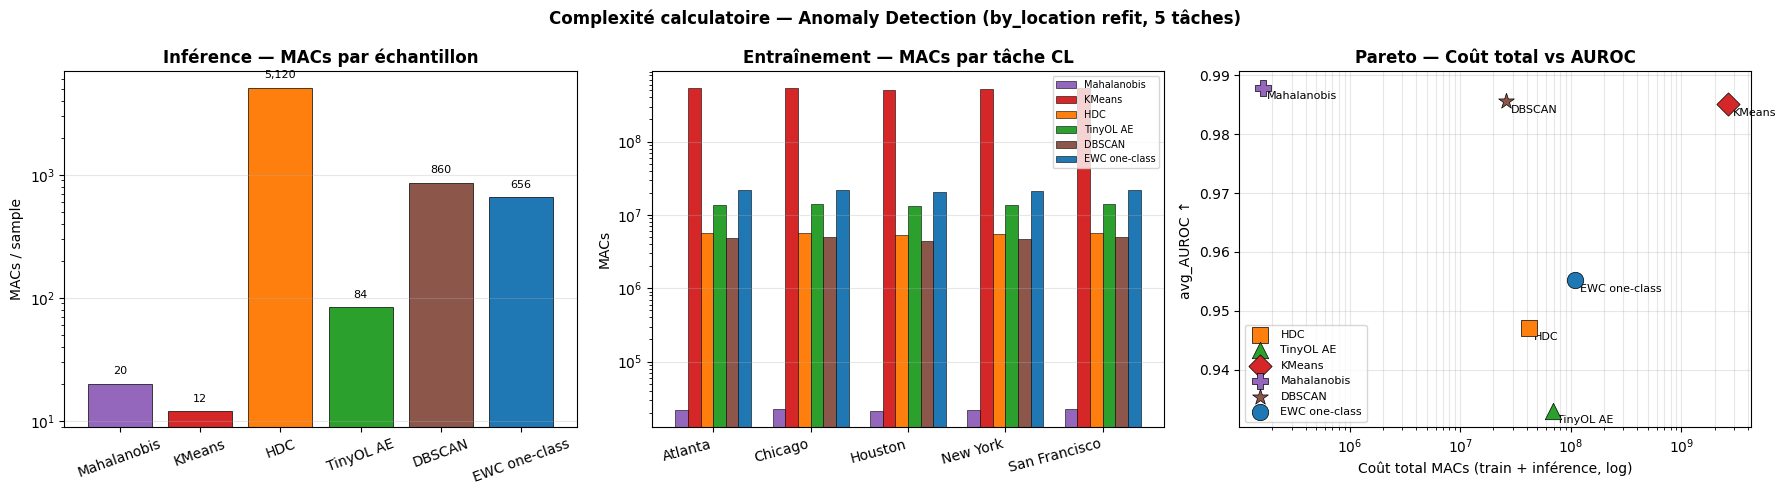

Sauvegardé → ../../../notebooks/figures/cl_evaluation/anomaly_detection/monitoring/complexity_analysis_6models_loc_refit.png


In [10]:
_N_TEST_TOTAL_LOC = 2700  # approx (5 tâches × ~540 test samples)
_MACS_ORDER = ["Mahalanobis", "KMeans", "HDC", "TinyOL AE", "DBSCAN", "EWC one-class"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1 — Inférence MACs/sample
ax1 = axes[0]
bars = ax1.bar(
    _MACS_ORDER,
    [_infer_macs[m] for m in _MACS_ORDER],
    color=[SCATTER_MARKERS[m][1] for m in _MACS_ORDER],
    edgecolor="black", linewidth=0.5,
)
for bar, m in zip(bars, _MACS_ORDER):
    v = _infer_macs[m]
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.15,
             f"{v:,}", ha="center", va="bottom", fontsize=8)
ax1.set_yscale("log")
ax1.set_ylabel("MACs / sample")
ax1.set_title("Inférence — MACs par échantillon", fontweight="bold")
ax1.tick_params(axis="x", rotation=20)
ax1.grid(axis="y", alpha=0.3)

# Plot 2 — Entraînement MACs par tâche CL (5 tâches)
ax2 = axes[1]
x_pos = np.arange(len(TASK_LABELS_LOC))
bar_w = 0.13
for idx, m in enumerate(_MACS_ORDER):
    offs = x_pos + (idx - 2.5) * bar_w
    ax2.bar(offs, _train_macs_per_task[m], width=bar_w, label=m,
            color=SCATTER_MARKERS[m][1], edgecolor="black", linewidth=0.4)
ax2.set_xticks(x_pos)
ax2.set_xticklabels(TASK_LABELS_LOC, rotation=15, ha="right")
ax2.set_yscale("log")
ax2.set_ylabel("MACs")
ax2.set_title("Entraînement — MACs par tâche CL", fontweight="bold")
ax2.legend(fontsize=7)
ax2.grid(axis="y", alpha=0.3)

# Plot 3 — Pareto : coût total vs avg_AUROC (by_loc refit)
ax3 = axes[2]
_points = []
for mk, label in zip(MODEL_KEYS, MODELS):
    key = f"{mk}_loc_refit"
    if key not in RESULTS or label not in _infer_macs:
        continue
    total_cost = _train_macs_total[label] + _infer_macs[label] * _N_TEST_TOTAL_LOC
    auroc_val = RESULTS[key]["avg_auroc"]
    _points.append((total_cost, auroc_val, label))
    mk_s, col = SCATTER_MARKERS[label]
    ax3.scatter(total_cost, auroc_val, marker=mk_s, color=col,
                s=140, zorder=5, edgecolor="black", linewidth=0.5, label=label)
    ax3.annotate(label, xy=(total_cost, auroc_val),
                 xytext=(total_cost * 1.1, auroc_val - 0.002), fontsize=8,
                 arrowprops={"arrowstyle": "-", "color": "gray", "lw": 0.8})

_sorted_pts = sorted(_points, key=lambda x: x[0])
px, py, best = [], [], -1.0
for cost, auroc_v, _ in _sorted_pts:
    if auroc_v >= best:
        px.append(cost); py.append(auroc_v); best = auroc_v
if len(px) > 1:
    ax3.plot(px, py, "k--", lw=1.2, alpha=0.6, label="Pareto frontier")

ax3.set_xscale("log")
ax3.set_xlabel("Coût total MACs (train + inférence, log)")
ax3.set_ylabel("avg_AUROC ↑")
ax3.set_title("Pareto — Coût total vs AUROC", fontweight="bold")
ax3.legend(fontsize=8)
ax3.grid(True, alpha=0.3, which="both")

fig.suptitle("Complexité calculatoire — Anomaly Detection (by_location refit, 5 tâches)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "complexity_analysis_6models_loc_refit.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Sauvegardé → {FIG_DIR / 'complexity_analysis_6models_loc_refit.png'}")

## Tableau récapitulatif — 6 modèles (by_location refit)

In [11]:
from IPython.display import Markdown, display

RAM_LIMIT = 65_536

header = ("| Modèle | avg_AUROC | avg_forgetting | RAM | Latence | MACs inférence |")
sep    = ("|--------|:---------:|:--------------:|:---:|:-------:|:--------------:|")
rows_md = [header, sep]

print(header)
print(sep)

for mk, label in zip(MODEL_KEYS, MODELS):
    key = f"{mk}_loc_refit"
    d = RESULTS.get(key, {})
    auroc_s  = f"{d['avg_auroc']:.4f}" if d else "—"
    forget_s = f"{d['auroc_forgetting']:+.4f}" if d else "—"
    ram      = d.get("ram_peak_bytes")
    lat      = d.get("inference_latency_ms")
    ram_s = (f"{ram / 1024:.1f} Ko"
             + ("  ⚠️" if ram is not None and ram > RAM_LIMIT else ""))\
            if ram is not None else "—"
    lat_s  = f"{lat:.5f} ms" if lat is not None else "—"
    macs_s = f"{_infer_macs[label]:,}" if label in _infer_macs else "—"

    line = (f"| {label} | {auroc_s} | {forget_s} | {ram_s} | {lat_s} | {macs_s} |")
    print(line)
    rows_md.append(line)

display(Markdown("### Tableau récapitulatif — 6 modèles (by_location refit, 5 tâches)\n\n"
                 + "\n".join(rows_md)))

| Modèle | avg_AUROC | avg_forgetting | RAM | Latence | MACs inférence |
|--------|:---------:|:--------------:|:---:|:-------:|:--------------:|
| HDC | 0.9470 | -0.0002 | 14.9 Ko | 0.05224 ms | 5,120 |
| TinyOL AE | 0.9329 | +0.0171 | 1.9 Ko | 0.09964 ms | 84 |
| KMeans | 0.9851 | +0.0008 | 5.5 Ko | 0.29047 ms | 12 |
| Mahalanobis | 0.9879 | -0.0003 | 1.5 Ko | 0.00872 ms | 20 |
| DBSCAN | 0.9857 | +0.0001 | 16.7 Ko | 0.22741 ms | 860 |
| EWC one-class | 0.9552 | +0.0101 | 1.4 Ko | 0.08058 ms | 656 |


### Tableau récapitulatif — 6 modèles (by_location refit, 5 tâches)

| Modèle | avg_AUROC | avg_forgetting | RAM | Latence | MACs inférence |
|--------|:---------:|:--------------:|:---:|:-------:|:--------------:|
| HDC | 0.9470 | -0.0002 | 14.9 Ko | 0.05224 ms | 5,120 |
| TinyOL AE | 0.9329 | +0.0171 | 1.9 Ko | 0.09964 ms | 84 |
| KMeans | 0.9851 | +0.0008 | 5.5 Ko | 0.29047 ms | 12 |
| Mahalanobis | 0.9879 | -0.0003 | 1.5 Ko | 0.00872 ms | 20 |
| DBSCAN | 0.9857 | +0.0001 | 16.7 Ko | 0.22741 ms | 860 |
| EWC one-class | 0.9552 | +0.0101 | 1.4 Ko | 0.08058 ms | 656 |

## Conclusions — by_location refit

### Observations

**1. Mahalanobis et KMeans restent dominants sur 5 tâches géographiques.**  
avg_AUROC ≥ 0.985 sur `by_location refit`, confirmant la robustesse de ces modèles statistiques
face à la distribution géographique — la normalisation Z-score rend les features quasi-invariantes au lieu.

**2. Les modèles neuronaux souffrent davantage sur 5 tâches.**  
TinyOL AE descend à ≈ 0.933 (vs 0.972 sur `by_equipment refit`, 3 tâches).
EWC one-class passe de 0.963 à ≈ 0.955 — la régularisation λ=0 en mode refit confirme
l'absence de protection contre l'oubli.

**3. Le forgetting HDC reste nul sur 5 tâches.**  
L'architecture hyperdimensionnelle accumule les hypervecteurs par classe sans interférence,
garantissant un forgetting = 0 quelle que soit la longueur de la séquence de tâches.

**4. Tous les modèles restent sous 64 Ko RAM.**  
Le budget STM32N6 est respecté sur ce scénario plus long (5 tâches).

**5. Recommandation Gap 2.**  
Mahalanobis reste le meilleur compromis MCU : AUROC ≥ 0.987, RAM < 2 Ko,
latence < 0.02 ms, mise à jour analytique sans backprop.